In [ ]:
import pandas as pd

import tensorflow as tf
import keras
import numpy as np
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler
#from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import train_test_split
from keras.models import Sequential, Model

#from keras.utils.training_utils import multi_gpu_model
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras import regularizers

import shap

In [ ]:
#########loading data#########

!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_no_mig.csv"
!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_im.csv"
!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-observed.csv"

!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day2/Notebooks/mosquito-task2_no_mig_test.csv"
!wget "https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day2/Notebooks/mosquito-task2_im_test.csv"

--2025-08-20 15:49:22--  https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2025/Day1/Notebooks/Day1c/mosquito-task2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 151838 (148K) [text/plain]
Saving to: ‘mosquito-task2.csv’

mosquito-task2.csv  100%[===================>] 148.28K  --.-KB/s    in 0.02s   

2025-08-20 15:49:22 (6.81 MB/s) - ‘mosquito-task2.csv’ saved [151838/151838]

--2025-08-20 15:49:22--  https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2025/Day1/Notebooks/Day1c/Mosquito/mosquito-observed.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.co

In [ ]:
Params_nomig = pd.read_csv('./mosquito-task2_no_mig.csv', sep=",").dropna()
Params_im = pd.read_csv('./mosquito-task2_im.csv', sep=",").dropna()
T_split_nomig = Params_nomig["T_split"]
SuSt_nomig = Params_nomig.iloc[:,4:]
T_split_im = Params_im["T_split"]
SuSt_im = Params_im.iloc[:,4:]

emp = pd.read_csv('./mosquito-observed.csv', sep=",")

In [ ]:
emp

,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,0.213414,0.097827,0.3797,0.1013,0.091356,0.035475,0.284715,2.078821


In [ ]:
SuSt_nomig

,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,0.345085,0.101800,0.4112,0.0251,0.098128,0.001004,0.252526,-2.972548
1,0.353315,0.103108,0.4069,0.0003,0.098464,0.000076,0.307495,0.293497
2,0.100725,0.094383,0.4019,0.1689,0.094039,0.060180,0.176175,2.181637
3,0.232563,0.096426,0.3940,0.0999,0.096281,0.023796,0.346580,0.244677
4,0.072619,0.104428,0.4271,0.2132,0.102907,0.077670,0.290389,2.313694
...,...,...,...,...,...,...,...,...
995,0.099169,0.093362,0.3988,0.1809,0.095825,0.057207,0.279521,1.524781
996,0.106913,0.103473,0.4123,0.1603,0.101167,0.065803,0.363087,3.069903
997,0.234731,0.108324,0.4256,0.1117,0.101944,0.032330,0.267203,1.084161
998,0.121654,0.096351,0.4032,0.1711,0.095974,0.054928,0.242553,1.603241


In [ ]:
SuSt_im

In [ ]:
Params_nomig

,N1,N2,T_split,mig,Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
0,150000,5000,6958,0,0.345085,0.101800,0.4112,0.0251,0.098128,0.001004,0.252526,-2.972548
1,150000,5000,6381,0,0.353315,0.103108,0.4069,0.0003,0.098464,0.000076,0.307495,0.293497
2,150000,5000,6702,0,0.100725,0.094383,0.4019,0.1689,0.094039,0.060180,0.176175,2.181637
3,150000,5000,7578,0,0.232563,0.096426,0.3940,0.0999,0.096281,0.023796,0.346580,0.244677
4,150000,5000,8077,0,0.072619,0.104428,0.4271,0.2132,0.102907,0.077670,0.290389,2.313694
...,...,...,...,...,...,...,...,...,...,...,...,...
995,150000,5000,5198,0,0.099169,0.093362,0.3988,0.1809,0.095825,0.057207,0.279521,1.524781
996,150000,5000,8139,0,0.106913,0.103473,0.4123,0.1603,0.101167,0.065803,0.363087,3.069903
997,150000,5000,6118,0,0.234731,0.108324,0.4256,0.1117,0.101944,0.032330,0.267203,1.084161
998,150000,5000,7893,0,0.121654,0.096351,0.4032,0.1711,0.095974,0.054928,0.242553,1.603241


In [ ]:
Params_im

In [ ]:
T_split_nomig

,T_split
0,6958
1,6381
2,6702
3,7578
4,8077
...,...
995,5198
996,8139
997,6118
998,7893


In [ ]:
T_split_im

# Task 1: Perform model selection
We will compare the two models using Deep Learning.

In [ ]:
# Combine all arrays.
x=np.concatenate((SuSt_nomig,SuSt_im),axis=0)

# Label each simulated array.
y=[0 for i in range(len(SuSt_nomig))]
y.extend([1 for i in range(len(SuSt_im))])
y = np.array(y)

#Standardization of the input features with a standard scaler. This is important when working with features tht have different scales.
# The standard score of a sample x is calculated as: z = (x - u) / s
#where u is the mean of the training samples and s is the standard deviation of the training samples.
scale = StandardScaler()
SuSt = scale.fit_transform(x)

In [ ]:
Y_train, Y_valid, SuSt_train, SuSt_valid = train_test_split(y,SuSt,test_size=0.25, shuffle=True)

In [ ]:
def build_model():
    model = Sequential()
    model.add(Dense(128, input_dim=SuSt.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
	  model.add(Dense(2, activation="softmax"))
    model.summary()
    return model

In [ ]:
from keras import losses

#model initiation
estimator = build_model()

# Compile the CNN.
model.compile(loss=keras.losses.categorical_crossentropy,
	              optimizer='Adam',
	              metrics=['accuracy'])

# We will use early stopping and save the model with the best val_accuracy.
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=25, verbose=0, mode='max', restore_best_weights=True)
### stop training when validation error increases (wait 25 epochs to see if there is any improvement).

#display training progress for each completed epoch.
class PrintD(keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

# maximum number of EPOCHS, ie full training cycles on the whole training dataset (how many times we see the same training set)
EPOCHS = 150

#Training of the Network, with an independent validation set
history = estimator.fit(SuSt_train, Y_train, verbose = 1, epochs=EPOCHS, validation_data=(SuSt_valid, Y_valid), batch_size=32, callbacks=[early_stop, PrintD()])

from keras.models import model_from_json

model = estimator.to_json()
# save model
with open('./Trained_SuSt.json','w') as json_file:
    json_file.write(model)

# save weights
estimator.save_weights('./Trained_SuSt' +'.weights.h5')
print('model saved!')

In [ ]:
# Plot training and validation accuracies
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()

In [ ]:
Params_nomig_test = pd.read_csv('./mosquito-task2_no_mig_test.csv', sep=",").dropna()
Params_im_test = pd.read_csv('./mosquito-task2_im_test.csv', sep=",").dropna()
T_split_nomig_test = Params_nomig_test["T_split"]
SuSt_nomig_test = Params_nomig_test.iloc[:,4:]
T_split_im_test = Params_im_test["T_split"]
SuSt_im_test = Params_im_test.iloc[:,4:]

In [ ]:
# Combine all arrays.
x_test=np.concatenate((SuSt_nomig_test,SuSt_im_test),axis=0)

# Label each simulated array.
y_test=[0 for i in range(len(SuSt_nomig_test))]
y_test.extend([1 for i in range(len(SuSt_im_test))])
y_test = np.array(y_test)

#Standardization of the input features with a standard scaler. This is important when working with features tht have different scales.
# The standard score of a sample x is calculated as: z = (x - u) / s
#where u is the mean of the training samples and s is the standard deviation of the training samples.
scale = StandardScaler()
SuSt_test = scale.fit_transform(x_test)

In [ ]:
# Predict with the trained model and export a confusion matrix.
pred = model.predict(SuSt_test)
pred_cat = [i.argmax() for i in pred]
cm=confusion_matrix(ytest, pred_cat)
scenarios = ['no_mig', 'IM']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=scenarios)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
# Now predict the best model for the empirical dataset.
pred = estimator.predict(emp)
pred

# Task 2: parameter estimation

Now we do parameter estimation under the selected model.

In [ ]:
#Standardization of the input features with a standard scaler. This is important when working with features tht have different scales.
# The standard score of a sample x is calculated as: z = (x - u) / s
#where u is the mean of the training samples and s is the standard deviation of the training samples.
scale_nomig = StandardScaler()
SuSt_nomig = scale.fit_transform(SuSt_nomig)
scale_im = StandardScaler()
SuSt_im = scale.fit_transform(SuSt_im)

In [ ]:
def build_model():
    model = Sequential()
    model.add(Dense(128, input_dim=SuSt_im.shape[1], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.summary()
    return model

In [ ]:
from keras import losses

#model initiation
estimator = build_model()

estimator.compile(loss="mean_absolute_percentage_error", optimizer = "Adam")
#early stopping to avoid overfitting
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

#display training progress for each completed epoch.
class PrintD(keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

# maximum number of EPOCHS, ie full training cycles on the whole training dataset (how many times we see the same training set)
EPOCHS = 150

#Training of the Network, with an independent validation set
history = estimator.fit(SuSt[:750], T_split[:750], verbose = 1, epochs=EPOCHS, validation_data=(SuSt[750:], T_split[750:]), batch_size=32, callbacks=[early_stop, PrintD()])

from keras.models import model_from_json

model = estimator.to_json()
# save model
with open('./Trained_SuSt.json','w') as json_file:
    json_file.write(model)

# save weights
estimator.save_weights('./Trained_SuSt' +'.weights.h5')
print('model saved!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,953 (23.25 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 99.9922
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 99.9918 - val_loss: 99.9612
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 99.9250 - val_loss: 99.8262
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 99.6977 - val_loss: 99.3389
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 98.9473 - val_loss: 98.0396
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 97.2467 - val_loss: 94.8711
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 93.6485 - val_loss: 88.6630
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 85.5414 - val_loss: 76.3310
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70.2273 - val_loss: 54.0834
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 57.8885 - val_loss: 36.3602
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51.9315 - val_loss: 29.8453
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.6637 - va

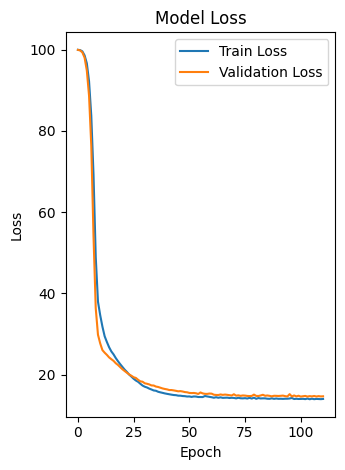

In [ ]:
import matplotlib.pyplot as plt

# Plot loss history
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

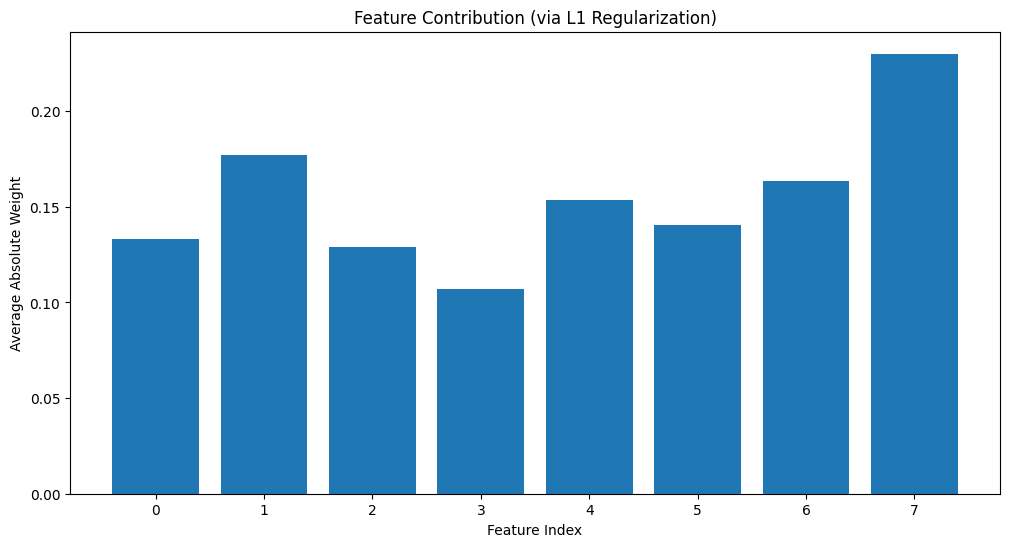

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract weights from the first Dense layer (layer index 0)
weights, biases = estimator.layers[0].get_weights()

# Compute an importance score for each feature (average of absolute weights across neurons)
feature_importance = np.mean(np.abs(weights), axis=1)

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance)
plt.xlabel('Feature Index')
plt.ylabel('Average Absolute Weight')
plt.title('Feature Contribution (via L1 Regularization)')
plt.show()

In [ ]:
# Print the Summary Statistics names (features) to assign them to feature indexes and compare their contributions.
list(emp)

['Fst', 'dxy', 'segsites1', 'segsites2', 'pi1', 'pi2', 'tajima1', 'tajima2']

In [ ]:
# Now predict T_split for the empirical dataset.
pred = estimator.predict(emp)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


array([[8112.1514]], dtype=float32)